In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm  # Progress bar
from statsmodels.tsa.arima.model import ARIMA


In [ ]:

# Path ke folder train dan test
base_path = "C:/KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA/KEGIATAN/ARKAVIDIA 9.0/Penyisihan/Harga Bahan Pangan"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")
sample_submission_path = os.path.join(base_path, "sample_submission.csv")

# Load sample submission
sample_submission = pd.read_csv(sample_submission_path)

# Dictionary untuk menyimpan semua prediksi
all_predictions = {}

# Ambil daftar file CSV dalam folder train dan test
train_files = sorted(glob.glob(os.path.join(train_path, "*.csv")))
test_files = sorted(glob.glob(os.path.join(test_path, "*.csv")))

# Buat set nama file tanpa ekstensi untuk pencocokan
train_names = {os.path.basename(f).replace(".csv", "") for f in train_files}
test_names = {os.path.basename(f).replace(".csv", "") for f in test_files}

# Ambil hanya nama file yang ada di kedua folder
common_names = train_names.intersection(test_names)

print(f"📂 Found {len(common_names)} matching files in train/ and test/: {common_names}")



### **ADE**

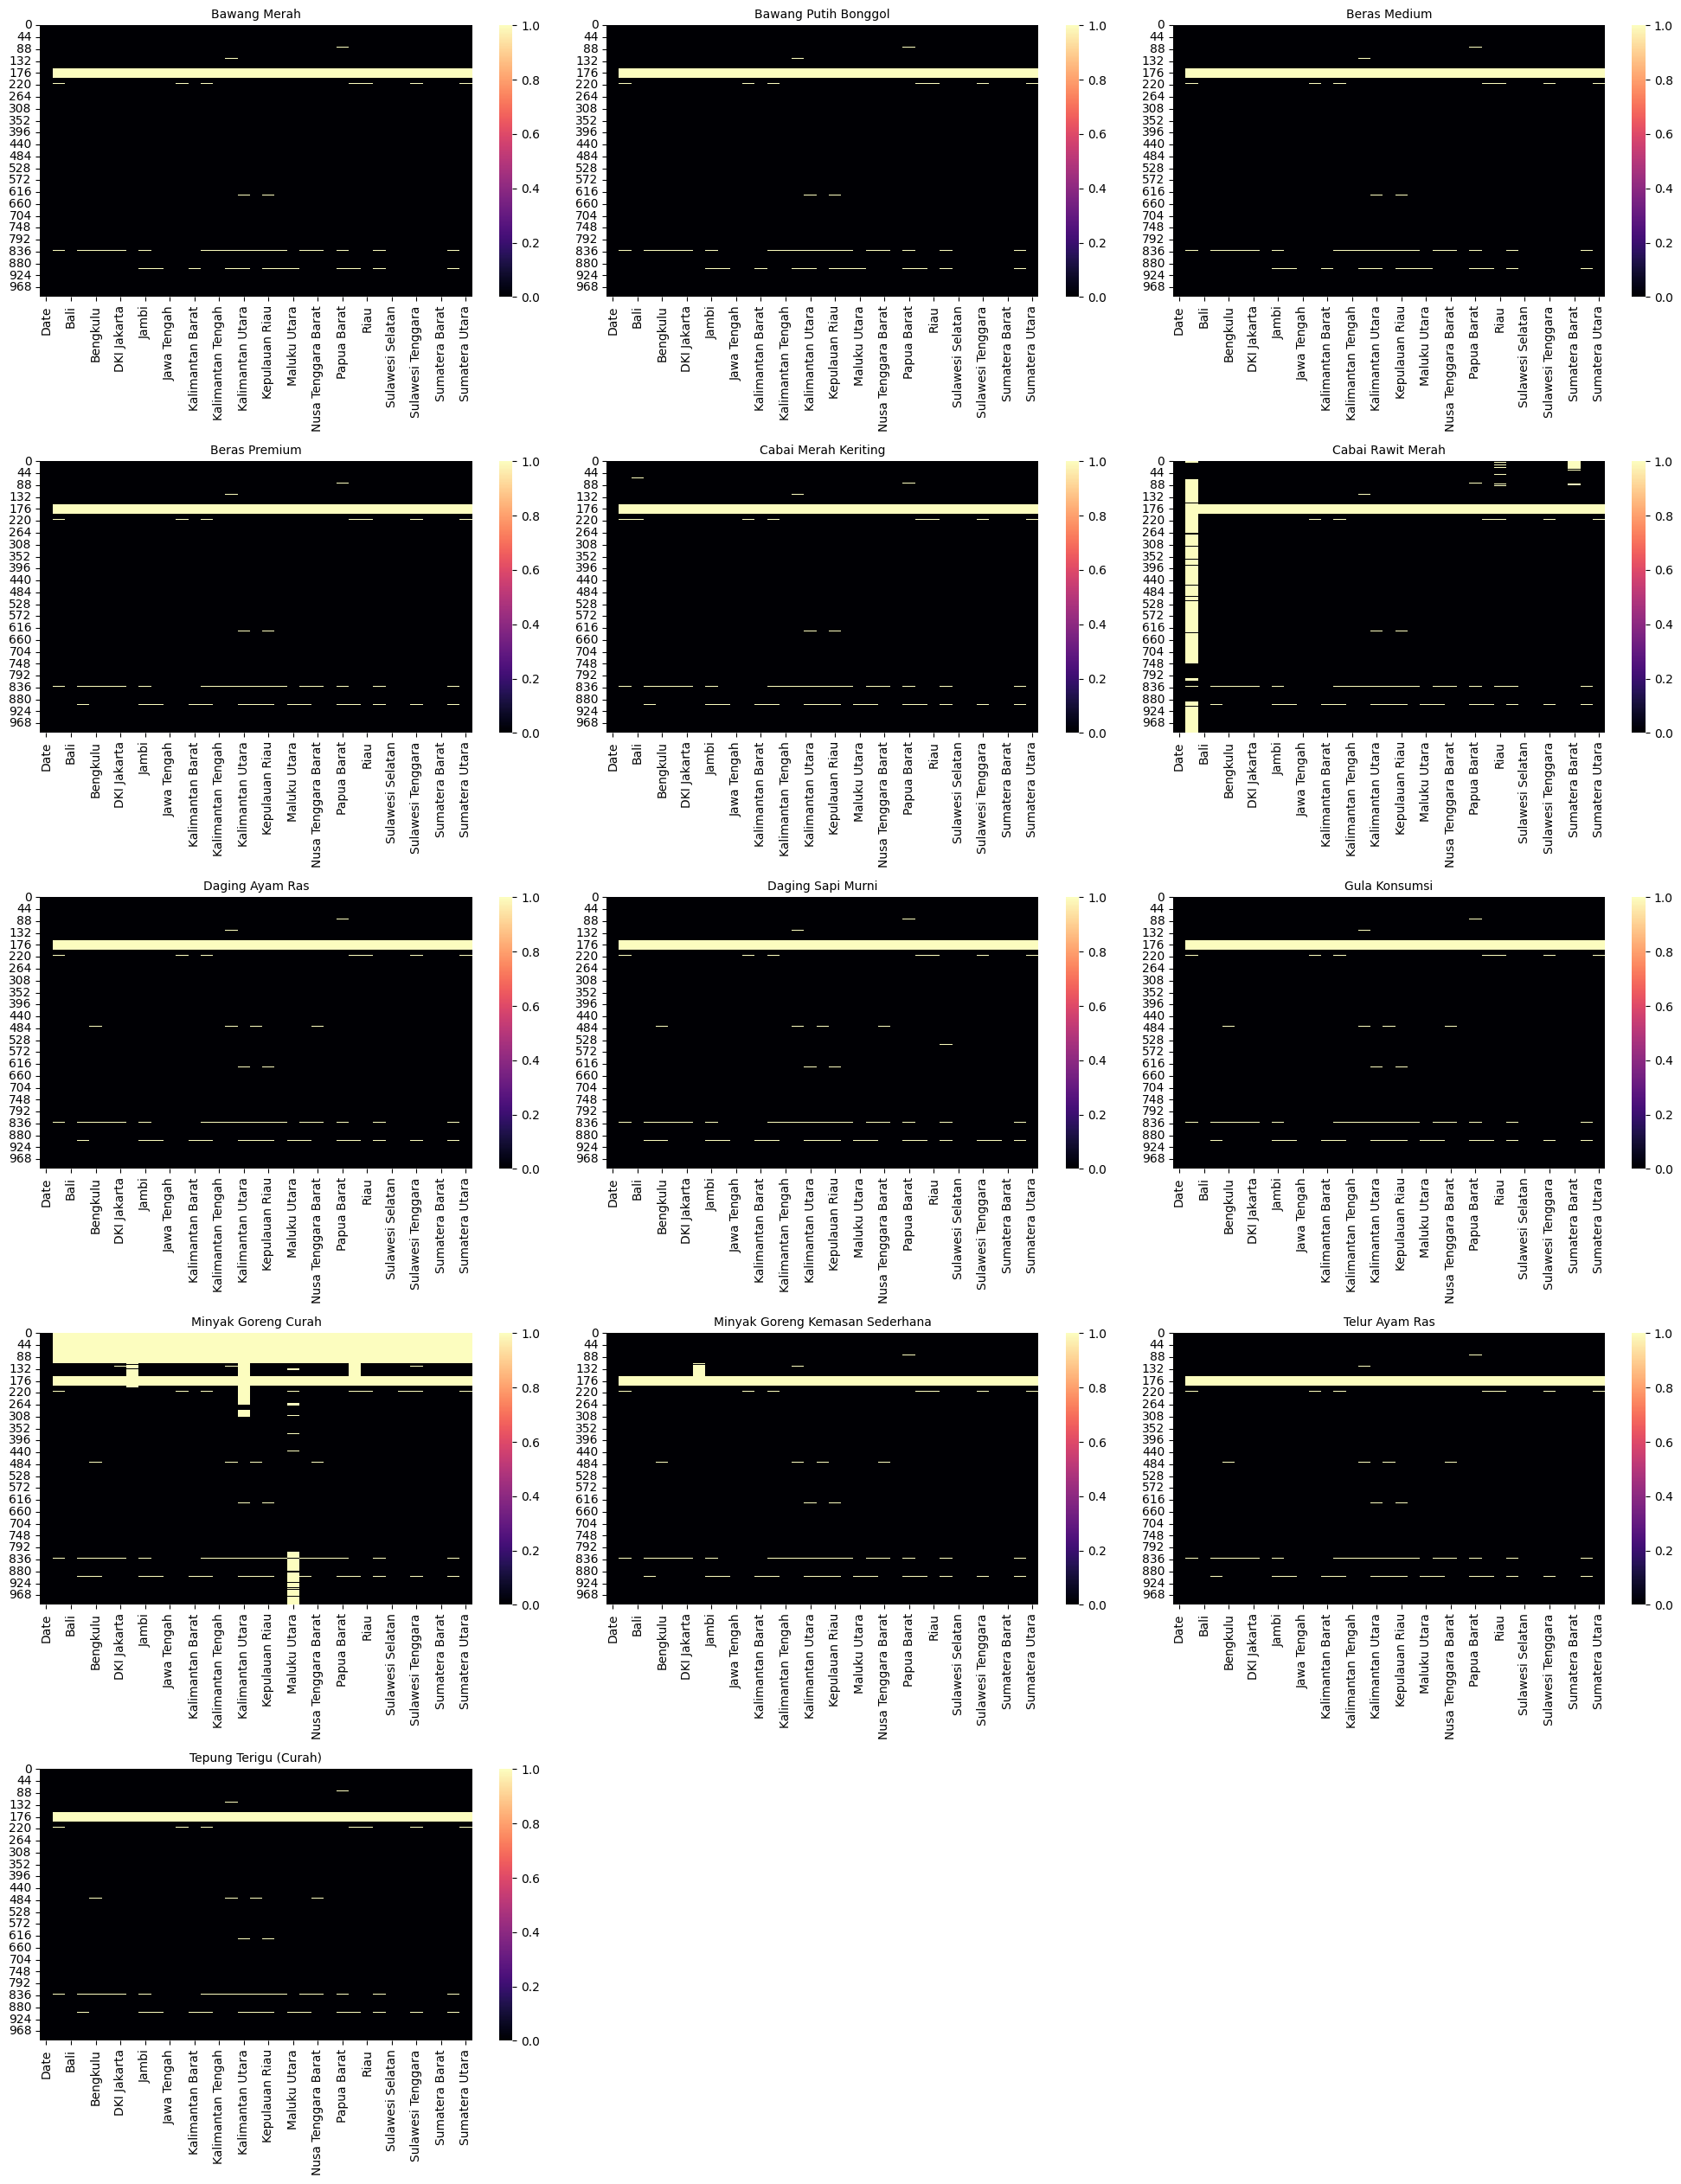

In [10]:
# Buat grid untuk menampilkan heatmap secara bersamaan
num_files = len(train_path)
num_cols = 3  # Jumlah kolom dalam grid
num_rows = (num_files // num_cols) + (num_files % num_cols > 0)  # Hitung jumlah baris yang dibutuhkan

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

# Loop untuk setiap file dalam train/ dan buat heatmap missing values
for i, file in enumerate(train_files):
    name = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file)
    
    # Konversi kolom 'Date' jika ada
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    
    # Buat heatmap missing values untuk setiap file dalam grid
    sns.heatmap(df.isnull(), cmap="magma", cbar=True, ax=axes[i])
    axes[i].set_title(f"{name}", fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)

# Hapus sisa subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

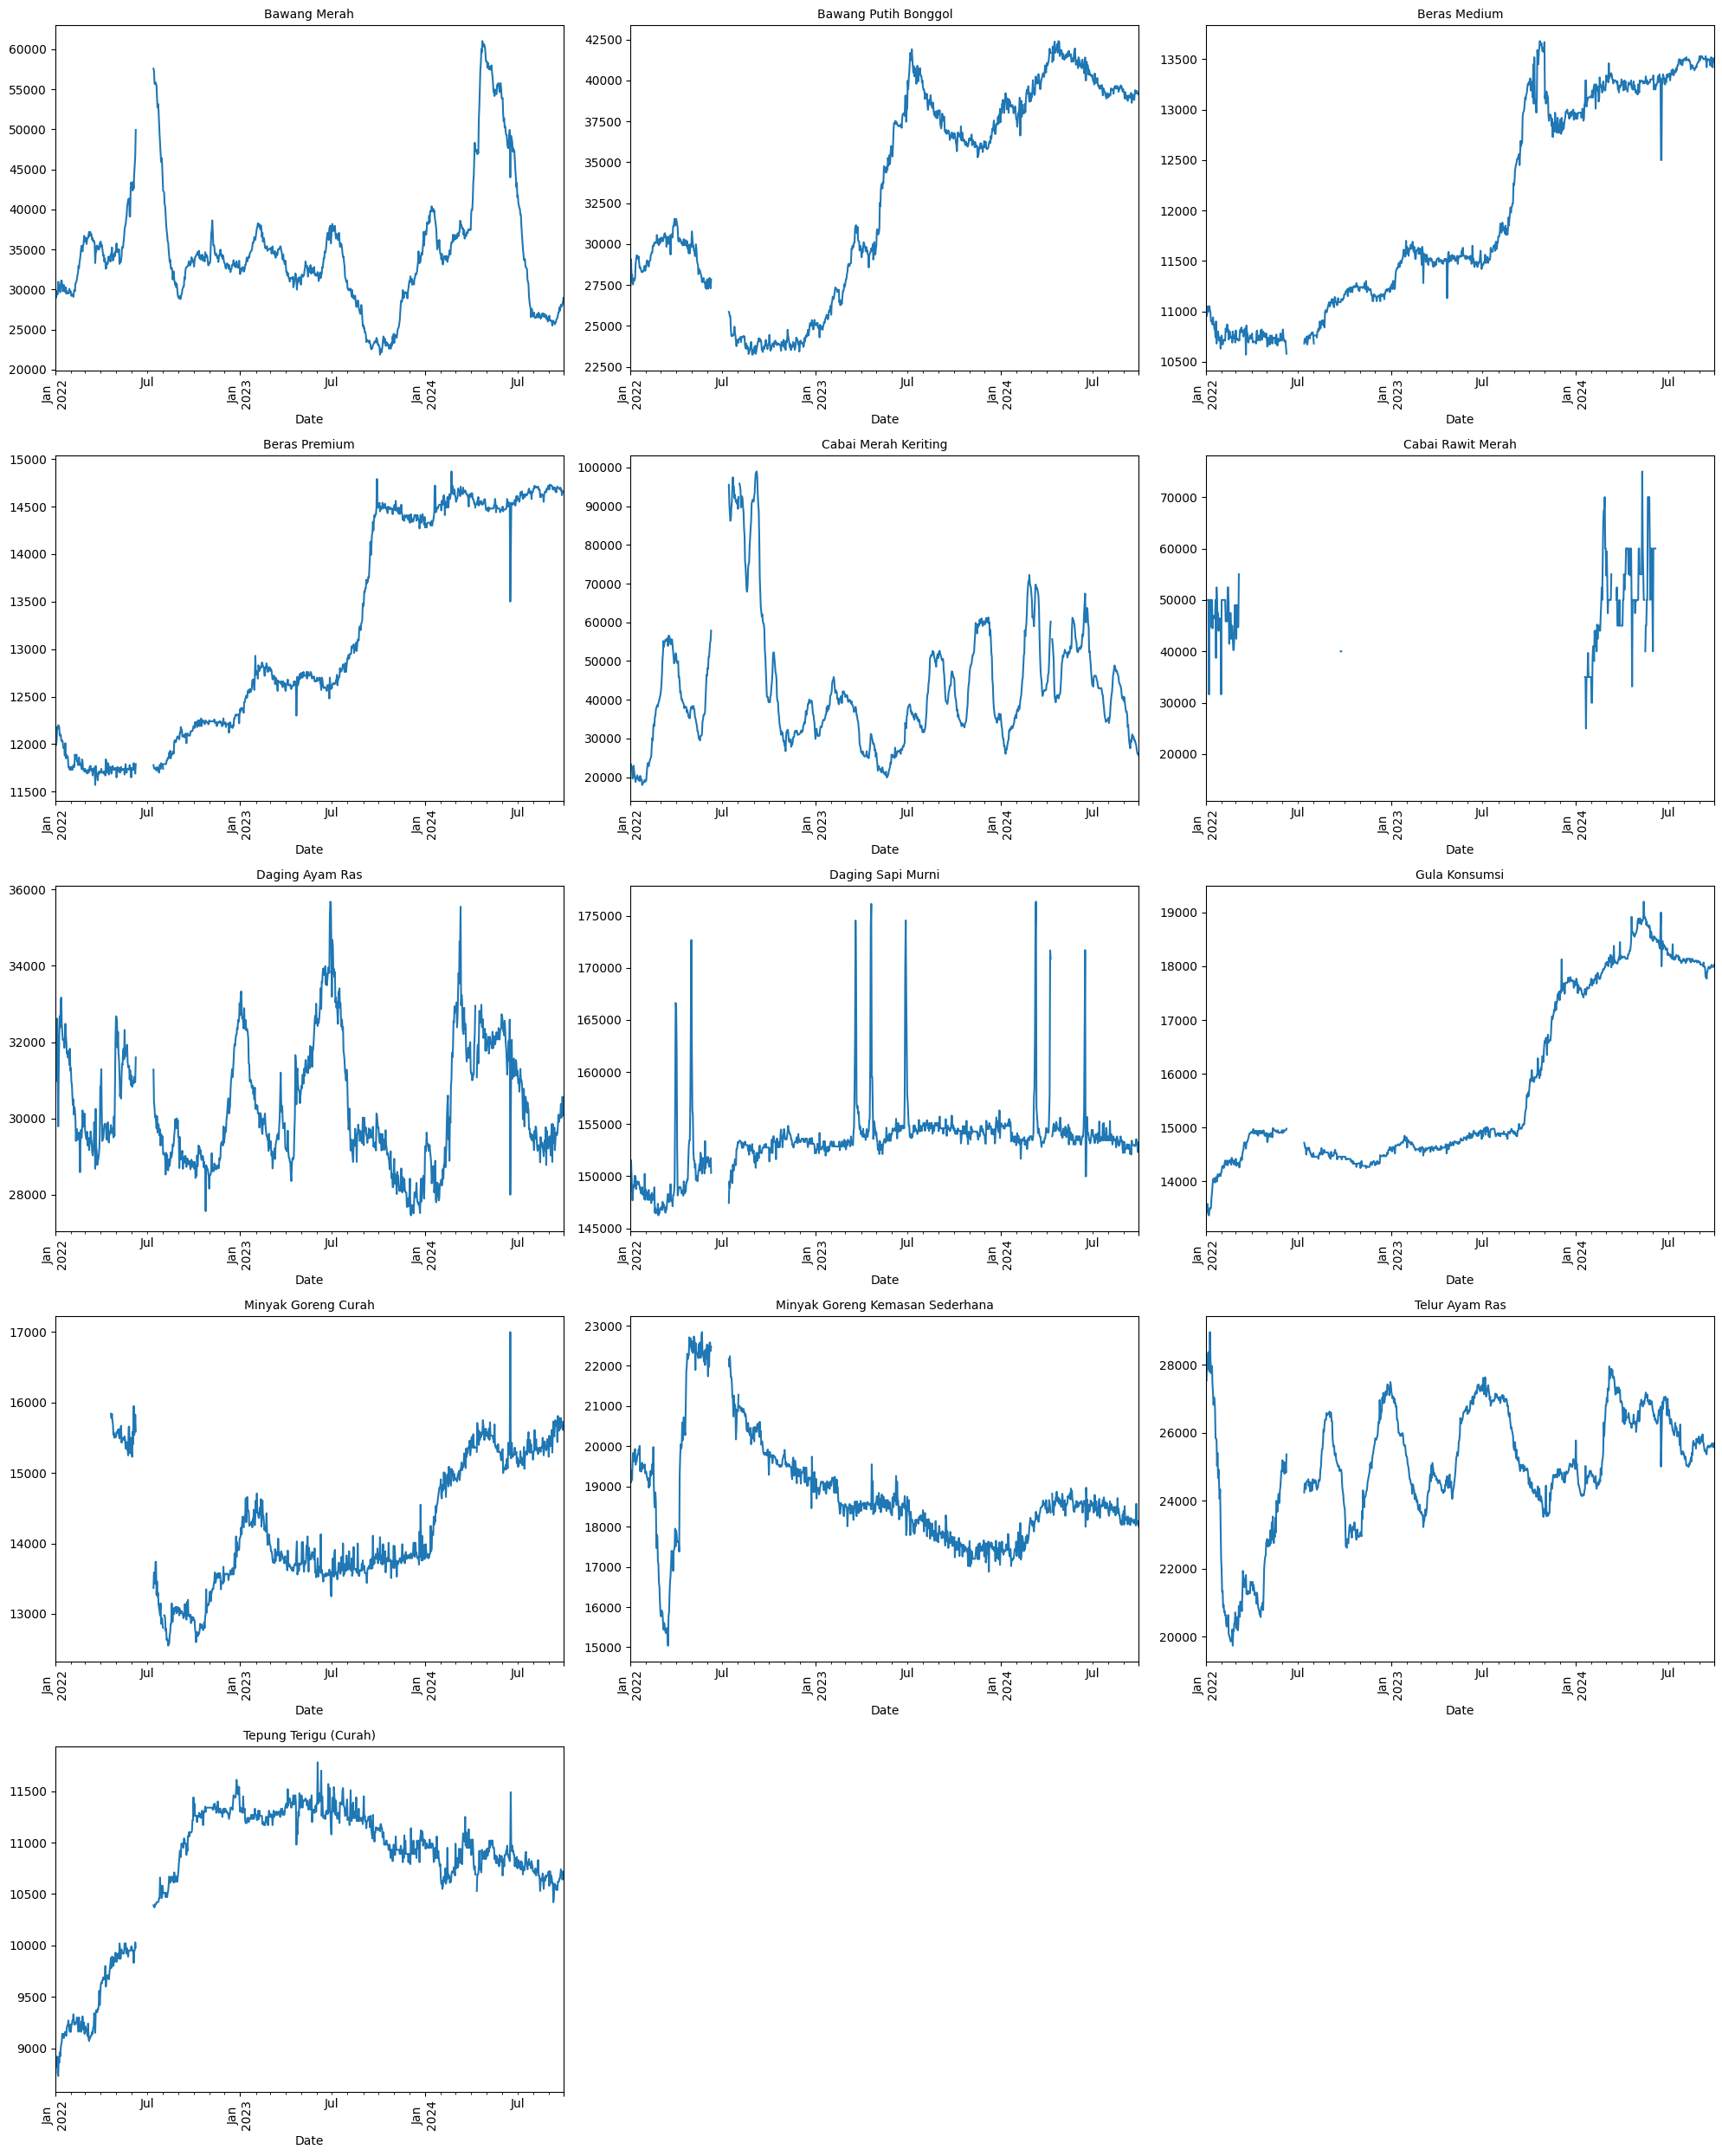

In [11]:
# Buat grid untuk menampilkan line chart secara bersamaan
num_files = len(train_files)
num_cols = 3  # Jumlah kolom dalam grid
num_rows = (num_files // num_cols) + (num_files % num_cols > 0)  # Hitung jumlah baris yang dibutuhkan

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

# Loop untuk setiap file dalam train/ dan buat line chart
for i, file in enumerate(train_files):
    name = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file)
    
    # Konversi kolom 'Date' jika ada
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.sort_values(by="Date")  # Pastikan data terurut berdasarkan tanggal
    
    # Plot line chart jika ada kolom numerik
    if "Date" in df.columns and "Aceh" in df.columns:
        df.set_index("Date")["Aceh"].plot(ax=axes[i], legend=False)
    
    axes[i].set_title(f"{name}", fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)

# Hapus sisa subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Buat grid untuk menampilkan line chart secara bersamaan
num_files = len(train_files)
num_cols = 3  # Jumlah kolom dalam grid
num_rows = (num_files // num_cols) + (num_files % num_cols > 0)  # Hitung jumlah baris yang dibutuhkan

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

# Loop untuk setiap file dalam train/ dan buat line chart
for i, file in enumerate(train_files):
    name = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file)
    
    # Konversi kolom 'Date' jika ada
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.sort_values(by="Date")  # Pastikan data terurut berdasarkan tanggal
    
    # Plot line chart jika ada kolom numerik
    if "Date" in df.columns and df.shape[1] > 1:
        df.set_index("Date").plot(ax=axes[i], legend=False)
    
    axes[i].set_title(f"{name}", fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)

# Hapus sisa subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## **INTERPOLASI**

**TIME INTERPOLASI**

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

# Path ke folder train
train_path = "C:/KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA/KEGIATAN/ARKAVIDIA 9.0/Penyisihan/Harga Bahan Pangan/train"

# Ambil daftar file CSV dalam folder train
train_files = sorted(glob.glob(os.path.join(train_path, "*.csv")))

# Daftar file yang akan diinterpolasi
files_to_interpolate = {
    "Bawang Merah", "Bawang Putih Bonggol", "Beras Medium", "Beras Premium", 
    "Daging Ayam Ras", "Daging Sapi Murni", "Gula Konsumsi", 
    "Minyak Goreng Kemasan Sederhana", "Telur Ayam Ras", "Tepung Terigu (Curah)"
}

# Buat grid untuk menampilkan line chart secara bersamaan
num_files = len(train_files)
num_cols = 3  # Jumlah kolom dalam grid
num_rows = (num_files // num_cols) + (num_files % num_cols > 0)  # Hitung jumlah baris yang dibutuhkan

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

# Loop untuk setiap file dalam train/ dan buat line chart dengan interpolasi sementara
for i, file in enumerate(train_files):
    name = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file)
    
    # Konversi kolom 'Date' jika ada
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.sort_values(by="Date")
        df.set_index("Date", inplace=True)
    
    # Lakukan interpolasi sementara hanya jika file ada dalam daftar
    if name in files_to_interpolate:
        df_interpolated = df.copy()
        for col in df.columns:
            df_interpolated[col] = df[col].interpolate(method="time")
    else:
        df_interpolated = df
    
    # Plot line chart jika ada kolom numerik
    if "Aceh" in df_interpolated.columns:
        df_interpolated["Aceh"].plot(ax=axes[i], legend=False)
    
    axes[i].set_title(f"{name}", fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)

# Hapus sisa subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**INTERPOLASI pchip**

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

# Path ke folder train
train_path = "C:/KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA/KEGIATAN/ARKAVIDIA 9.0/Penyisihan/Harga Bahan Pangan/train"

# Ambil daftar file CSV dalam folder train
train_files = sorted(glob.glob(os.path.join(train_path, "*.csv")))

# Buat grid untuk menampilkan line chart secara bersamaan
num_files = len(train_files)
num_cols = 3  # Jumlah kolom dalam grid
num_rows = (num_files // num_cols) + (num_files % num_cols > 0)  # Hitung jumlah baris yang dibutuhkan

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

# Loop untuk setiap file dalam train/ dan buat line chart dengan interpolasi linear
for i, file in enumerate(train_files):
    name = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file)
    
    # Konversi kolom 'Date' jika ada
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.sort_values(by="Date")
        df.set_index("Date", inplace=True)
    
    # Lakukan interpolasi linear untuk semua kolom numerik
    df_interpolated = df.copy()
    for col in df.columns:
        df_interpolated[col] = df[col].interpolate(method="linear")
    
    # Plot line chart jika ada kolom numerik
    if "Aceh" in df_interpolated.columns:
        df_interpolated["Aceh"].plot(ax=axes[i], label="Aceh", color="blue")
    if "Sumatera Utara" in df_interpolated.columns:
        df_interpolated["Sumatera Utara"].plot(ax=axes[i], label="Sumatera Utara", color="red")
    
    axes[i].set_title(f"{name}", fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].legend()

# Hapus sisa subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

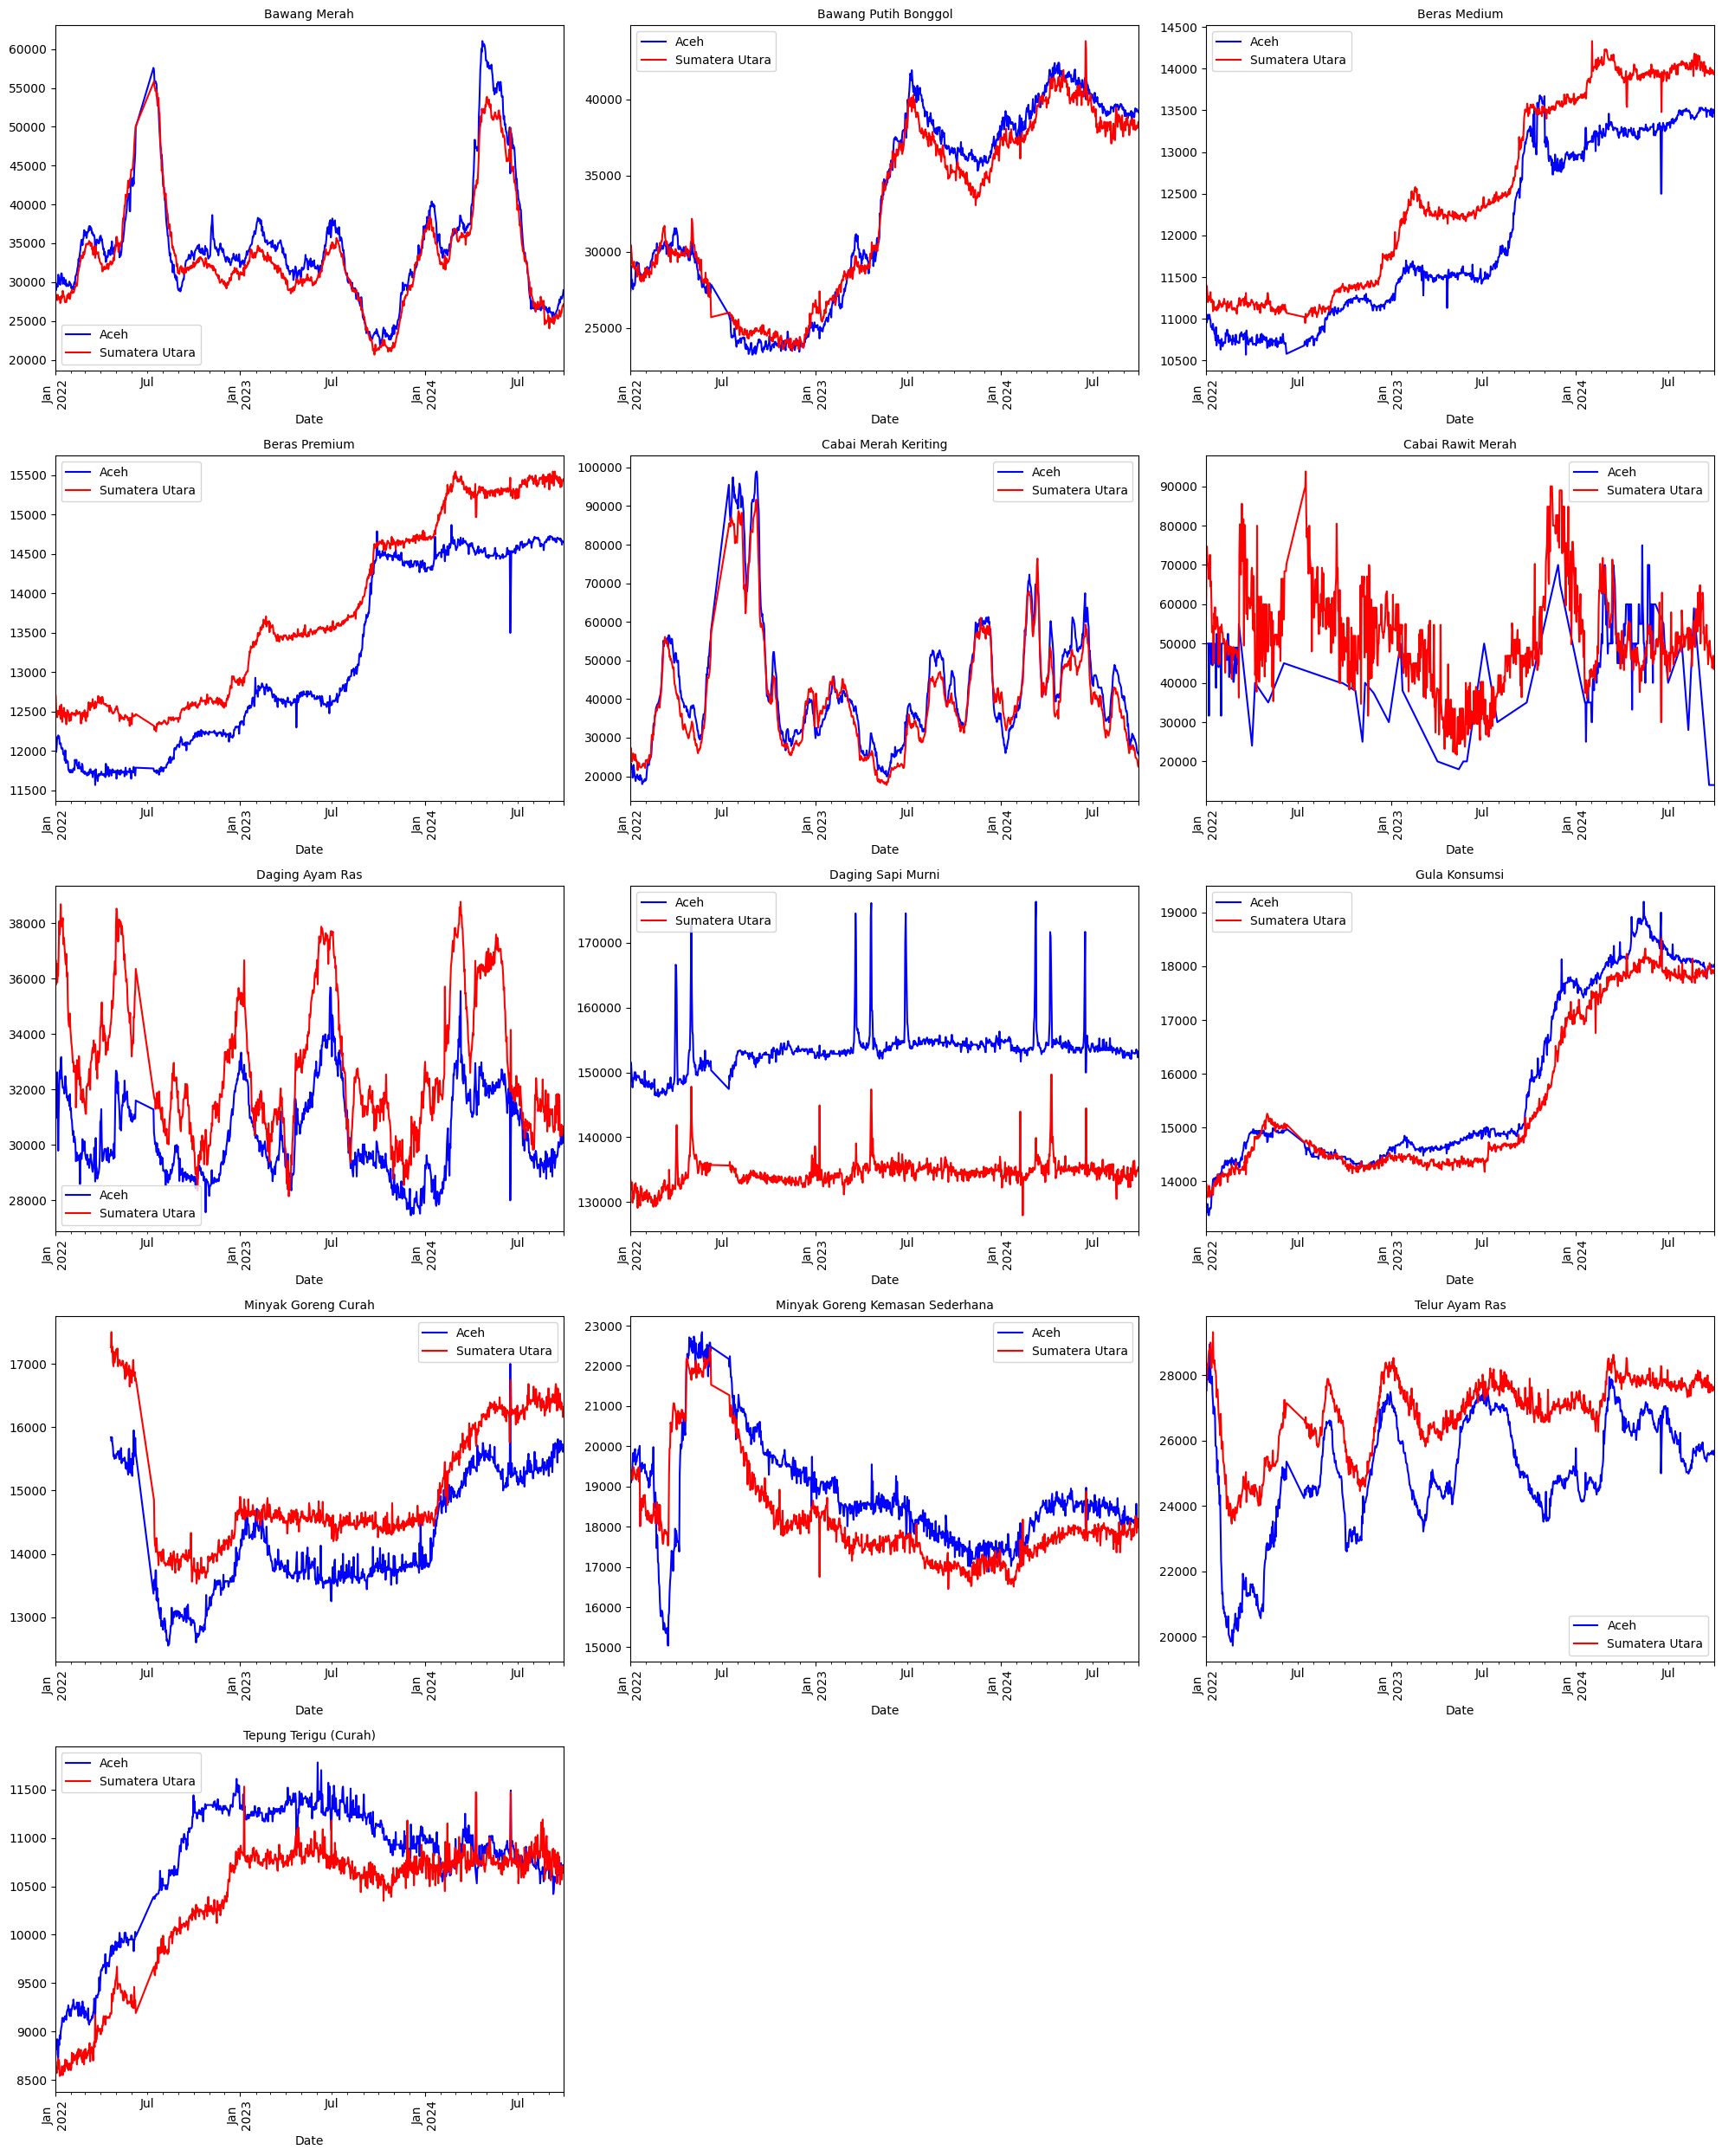


===== Uji Stasioneritas (ADF Test) =====

Bawang Merah:
  - Aceh: p-value = 0.00919 (Stasioner)
  - Bali: p-value = 0.00767 (Stasioner)
  - Banten: p-value = 0.01813 (Stasioner)
  - Bengkulu: p-value = 0.01936 (Stasioner)
  - DI Yogyakarta: p-value = 0.01951 (Stasioner)
  - DKI Jakarta: p-value = 0.04449 (Stasioner)
  - Gorontalo: p-value = 0.00667 (Stasioner)
  - Jambi: p-value = 0.01115 (Stasioner)
  - Jawa Barat: p-value = 0.01648 (Stasioner)
  - Jawa Tengah: p-value = 0.00948 (Stasioner)
  - Jawa Timur: p-value = 0.02327 (Stasioner)
  - Kalimantan Barat: p-value = 0.00558 (Stasioner)
  - Kalimantan Selatan: p-value = 0.00411 (Stasioner)
  - Kalimantan Tengah: p-value = 0.01696 (Stasioner)
  - Kalimantan Timur: p-value = 0.00769 (Stasioner)
  - Kalimantan Utara: p-value = 0.01298 (Stasioner)
  - Kepulauan Bangka Belitung: p-value = 0.01494 (Stasioner)
  - Kepulauan Riau: p-value = 0.07763 (Tidak Stasioner)
  - Lampung: p-value = 0.09689 (Tidak Stasioner)
  - Maluku Utara: p-value =

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
from statsmodels.tsa.stattools import adfuller  # Uji stasioneritas
from statsmodels.stats.diagnostic import acorr_ljungbox  # Uji Ljung-Box

warnings.filterwarnings("ignore")

# Path ke folder train
train_path = "C:/KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA/KEGIATAN/ARKAVIDIA 9.0/Penyisihan/Harga Bahan Pangan/train"

# Ambil daftar file CSV dalam folder train
train_files = sorted(glob.glob(os.path.join(train_path, "*.csv")))

# Buat grid untuk menampilkan line chart secara bersamaan
num_files = len(train_files)
num_cols = 3  # Jumlah kolom dalam grid
num_rows = (num_files // num_cols) + (num_files % num_cols > 0)  # Hitung jumlah baris yang dibutuhkan

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

# Loop untuk setiap file dalam train/ dan buat line chart dengan interpolasi linear
for i, file in enumerate(train_files):
    name = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file)
    
    # Konversi kolom 'Date' jika ada
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.sort_values(by="Date")
        df.set_index("Date", inplace=True)
    
    # Lakukan interpolasi linear untuk semua kolom numerik
    df_interpolated = df.copy()
    for col in df.columns:
        df_interpolated[col] = df[col].interpolate(method="linear")
    
    # Plot line chart jika ada kolom numerik
    if "Aceh" in df_interpolated.columns:
        df_interpolated["Aceh"].plot(ax=axes[i], label="Aceh", color="blue")
    if "Sumatera Utara" in df_interpolated.columns:
        df_interpolated["Sumatera Utara"].plot(ax=axes[i], label="Sumatera Utara", color="red")
    
    axes[i].set_title(f"{name}", fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].legend()

# Hapus sisa subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [ ]:
# ============================
# Uji Stasioneritas (ADF Test)
# ============================
stationarity_results = {}

for file in train_files:
    name = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file)
    
    # Uji ADF untuk setiap provinsi
    adf_results = {}
    for col in df_interpolated.columns:
        result = adfuller(df_interpolated[col].dropna(), autolag="AIC")
        p_value = result[1]
        adf_results[col] = p_value
    
    stationarity_results[name] = adf_results

# ============================
# Menampilkan Hasil Uji ADF
# ============================
print("\n===== Uji Stasioneritas (ADF Test) =====")
for file, results in stationarity_results.items():
    print(f"\n{file}:")
    for province, p_value in results.items():
        status = "Stasioner" if p_value < 0.05 else "Tidak Stasioner"
        print(f"  - {province}: p-value = {p_value:.5f} ({status})")




===== Uji Stasioneritas (ADF Test) =====

Bawang Merah:
  - Aceh: p-value = 0.00919 (Stasioner)
  - Bali: p-value = 0.00767 (Stasioner)
  - Banten: p-value = 0.01813 (Stasioner)
  - Bengkulu: p-value = 0.01936 (Stasioner)
  - DI Yogyakarta: p-value = 0.01951 (Stasioner)
  - DKI Jakarta: p-value = 0.04449 (Stasioner)
  - Gorontalo: p-value = 0.00667 (Stasioner)
  - Jambi: p-value = 0.01115 (Stasioner)
  - Jawa Barat: p-value = 0.01648 (Stasioner)
  - Jawa Tengah: p-value = 0.00948 (Stasioner)
  - Jawa Timur: p-value = 0.02327 (Stasioner)
  - Kalimantan Barat: p-value = 0.00558 (Stasioner)
  - Kalimantan Selatan: p-value = 0.00411 (Stasioner)
  - Kalimantan Tengah: p-value = 0.01696 (Stasioner)
  - Kalimantan Timur: p-value = 0.00769 (Stasioner)
  - Kalimantan Utara: p-value = 0.01298 (Stasioner)
  - Kepulauan Bangka Belitung: p-value = 0.01494 (Stasioner)
  - Kepulauan Riau: p-value = 0.07763 (Tidak Stasioner)
  - Lampung: p-value = 0.09689 (Tidak Stasioner)
  - Maluku Utara: p-value =

In [16]:
# ============================
# Menampilkan Hasil Uji White Noise (Hanya yang White Noise)
# ============================
print("\n===== Hasil Uji White Noise (Ljung-Box Test) =====")
any_white_noise = False

for file, results in white_noise_results.items():
    white_noise_provinces = {province: p_value for province, p_value in results.items() if p_value > 0.05}
    
    if white_noise_provinces:  # Cek apakah ada provinsi dengan White Noise
        any_white_noise = True
        print(f"\n{file}:")
        for province, p_value in white_noise_provinces.items():
            print(f"  - {province}: p-value = {p_value:.5f} (White Noise)")

# Jika tidak ada White Noise sama sekali, beri pesan
if not any_white_noise:
    print("\nTidak ada provinsi yang memenuhi asumsi White Noise.")



===== Hasil Uji White Noise (Ljung-Box Test) =====

Tidak ada provinsi yang memenuhi asumsi White Noise.


In [20]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import shapiro

# ============================
# Menampilkan Hanya Data yang Normal
# ============================
print("\n===== Uji Normalitas (Shapiro-Wilk Test) =====")
normal_found = False  # Flag untuk mengecek apakah ada data yang normal

for file, results in normality_results.items():
    normal_provinces = {province: p_value for province, p_value in results.items() if p_value > 0.05}
    
    if normal_provinces:
        normal_found = True
        print(f"\n{file}:")
        for province, p_value in normal_provinces.items():
            print(f"  - {province}: p-value = {p_value:.5f} (Normal)")

if not normal_found:
    print("\nTidak ada provinsi yang memenuhi asumsi normalitas.")



===== Uji Normalitas (Shapiro-Wilk Test) =====

Cabai Merah Keriting:
  - Maluku: p-value = 0.06204 (Normal)

Daging Ayam Ras:
  - Nusa Tenggara Barat: p-value = 0.17289 (Normal)


**AUTO SARIMA**

In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from joblib import Parallel, delayed

def find_best_sarima(y_train):
    """ Mencari parameter (p, d, q) dan (P, D, Q, m) terbaik menggunakan auto_arima """
    try:
        model = auto_arima(y_train, seasonal=True, stepwise=True, suppress_warnings=True, error_action="ignore", m=7)
        best_order = model.order
        best_seasonal_order = model.seasonal_order
        best_aic = model.aic()
        print(f"✅ Auto SARIMA sukses: Best order = {best_order}, Seasonal order = {best_seasonal_order}, AIC = {best_aic}")
        return best_order, best_seasonal_order
    except Exception as e:
        print(f"⚠️ Auto SARIMA gagal: {e}, menggunakan default (3,1,5) dan (1,1,1,7)")
        return (3, 1, 5), (1, 1, 1, 7)

def train_sarima_for_province(commodity, col, train_df, test_df):
    """ Fungsi untuk melatih SARIMA dengan parameter terbaik dari auto_arima """
    try:
        y_train = train_df[col].dropna()

        # Cari kombinasi (p, d, q) dan (P, D, Q, m) terbaik dengan auto_arima
        best_order, best_seasonal_order = find_best_sarima(y_train)

        # Latih model SARIMA dengan parameter terbaik
        model = SARIMAX(y_train, order=best_order, seasonal_order=best_seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit()

        # Prediksi dengan model terbaik
        y_pred = model_fit.forecast(steps=len(test_df))

        return col, y_pred.values, best_order, best_seasonal_order  # Mengembalikan best_order dan best_seasonal_order
    except Exception as e:
        print(f"⚠️ Error processing {commodity} - {col}: {e}")
        return col, np.full(len(test_df), np.nan), None, None  # Jika error, isi dengan NaN

def main():
    # Dictionary untuk menyimpan semua prediksi dan best order
    all_predictions = {}
    all_best_orders = {}  # Menyimpan best order untuk setiap provinsi

    # Loop melalui setiap file yang cocok di folder train
    for commodity in tqdm(common_names, desc="Processing Files", unit="file"):
        print(f"\n⏳ Processing: {commodity}...")

        train_file = os.path.join(train_path, f"{commodity}.csv")
        test_file = os.path.join(test_path, f"{commodity}.csv")

        # Load data train dan test
        train_df = pd.read_csv(train_file)
        test_df = pd.read_csv(test_file)

        # Konversi Date ke datetime
        train_df["Date"] = pd.to_datetime(train_df["Date"])
        test_df["Date"] = pd.to_datetime(test_df["Date"])

        # Tentukan kolom provinsi (semua selain Date)
        province_cols = [col for col in train_df.columns if col != "Date"]

        # Tangani missing value
        for col in province_cols:
            train_df[col] = train_df[col].interpolate(method="linear", limit_direction="both")
            train_df[col] = train_df[col].ffill().bfill()

        # Jalankan SARIMA untuk semua provinsi secara paralel 🔥
        results = Parallel(n_jobs=-1)(
            delayed(train_sarima_for_province)(commodity, col, train_df, test_df)
            for col in tqdm(province_cols, desc=f"Training {commodity}", leave=False)
        )

        # Simpan hasil prediksi & best order
        predictions = {col: y_pred for col, y_pred, _, _ in results}
        best_orders = {col: (order, seasonal_order) for col, _, order, seasonal_order in results}

        for col in province_cols:
            print(f"✅ {commodity} - {col} Done!")  

        # Simpan best order di dictionary
        all_best_orders[commodity] = best_orders

        # Buat DataFrame hasil prediksi
        submission = test_df[['Date']].copy()
        for col in province_cols:
            submission[col] = predictions[col]

        # Format tanggal
        submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")

        # Simpan prediksi dalam format dictionary sesuai sample_submission
        for col in province_cols:
            for date, value in zip(submission["Date"], submission[col]):
                key = f"{commodity}/{col}/{date}"
                all_predictions[key] = value

        print(f"✅ {commodity} processing completed!")

    # Cetak best order setelah semua selesai
    print("\n📊 Best Order Summary:")
    for commodity, orders in all_best_orders.items():
        for col, (order, seasonal_order) in orders.items():
            print(f"🔍 {commodity} - {col}: Best order = {order}, Seasonal order = {seasonal_order}")

    # Susun hasil akhir sesuai sample_submission
    sample_submission["price"] = sample_submission["id"].map(all_predictions)

    # Simpan hasil akhir
    output_path = "C:/KULIAH STATISTIKA UNIVERSITAS SYIAH KUALA/KEGIATAN/ARKAVIDIA 9.0/Penyisihan/Submisi/sarima.csv"
    sample_submission.to_csv(output_path, index=False)

    print(f"\n🎉 Prediksi SARIMA telah disimpan dalam '{output_path}'")

if __name__ == "__main__":
    main()
